# Viscosity Interpolation

Some tests, examples of viscosity interpolation

As a rule, visoscity varies exponentially with temperature, so that's how we onterpolatie it

But something seemed wrong with some dat from LSFOs

Here's a check, using the KinematicViscosity Object from adios_db.computation

## Conclusion so far:

The fit to an exponential works well for crude oils -- which is what we determined way back when.

However -- it works really poorly for at least some ULSFOs -- maybe other distilled products as well.

## Solution?

First step is to check the residuals, and at least issue a warning.

Next step is to come up with a better interolatio method -- we could do piecwise (linear or exponential), but thatmight extrapolate really badly. That may not be SO bad for environmental conditions -- not a huge temp range --  but not great for labeling and the like.

I tried using only the outside two pooints -- not good.

Could a 3 parameter exponential fit work? IN theory, it should't -- viscosity should tend to zero at infinite temperature, but maybe it wold work OK locally -- at least it would exactly fit three points :-)

Hmm -- piecewise exponential, with the extrapolation using a the fit to the end points?




In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot  as plt
import matplotlib
import adios_db.scripting as ads
import adios_db.computation.physical_properties as pp
import csv
import nucos

In [2]:
# Here's an LSFO with dynamic viscosity data:
EXAMPLE_DATA_DIR = Path(r"C:\Users\rintaro.moriyasu\Oil Databases\noaa-oil-data\data\oil")

with open("viscosity_data.csv") as infile:
    reader = csv.reader(infile)
    next(reader)
    oil_ids = [row[2].strip() for row in reader]

json_files = [EXAMPLE_DATA_DIR/id[:2]/(id+".json") for id in oil_ids]
#print(json_files)

In [3]:
oils = [ads.Oil.from_file(filename) for filename in json_files]

Skipping AD00813
Skipping AD01266
Skipping AD01483
Skipping AD02078
Skipping AD02082
Skipping AD02132
Skipping AD02151
Skipping AD02206
Skipping AD02270
Error in convert(), obj: DynamicViscosity(value=2170.0, unit='mPa.s', standard_deviation='ESTS 12.05/1.0/M', unit_type='dynamicviscosity')
Error in convert(), obj: DynamicViscosity(value=24000.0, unit='mPa.s', standard_deviation='ESTS 12.05/1.0/M', unit_type='dynamicviscosity')
Skipping NO00119
Skipping NO00122
Skipping NO00123


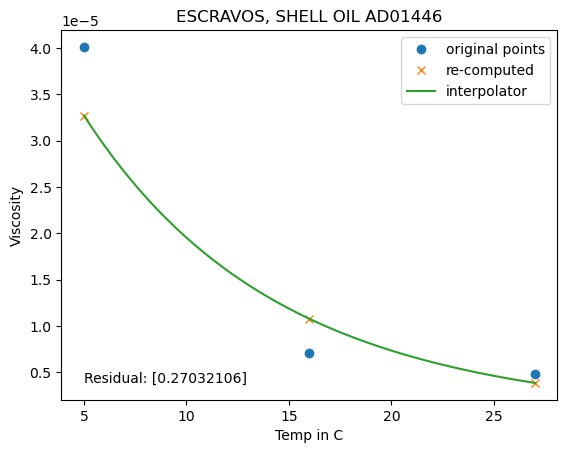

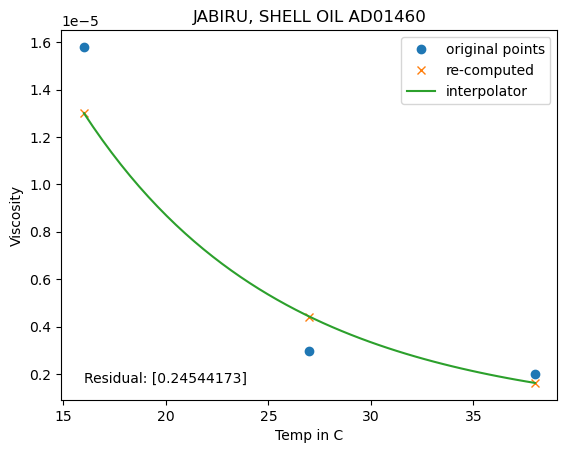

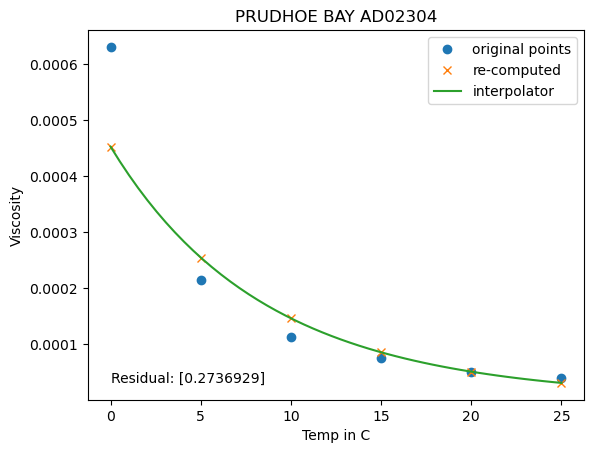

In [10]:
residuals = {}
no_list = ['AD00813', 'NO00119', 'NO00120','NO00121','NO00122', 'AD02582', 'AD01485' ]
matplotlib.rcParams['figure.max_open_warning'] = 240
for oil in oils[:]:
    validation = oil.validate()
    bad_oil = False
    for message in validation:
        if message.startswith("E062"):
            print("Skipping", oil.oil_id)
            bad_oil = True
            break
    if oil.oil_id in no_list:
        continue
    if bad_oil:
        continue
    
        
    oil_name = oil.metadata.name
    #print(oil_name)
    KV = pp.KinematicViscosity(oil)

    visc = KV.kviscs
    if len(visc) < 3:
        continue
    if KV.residuals[0] < 0.2:
        continue
    temps = np.array(KV.temps)
    visc2 = KV.at_temp(temps)
    residuals[oil.oil_id] = KV.residuals[0]
    temps_c = nucos.convert("K", "C", temps)
    temps3 = np.linspace(min(temps), max(temps))
    temps3_c = nucos.convert("K", "C", temps3)
    visc3 = KV.at_temp(temps3)
    fig, ax = plt.subplots()
    ax.set_title(oil_name +" " + oil.oil_id)
    ax.plot(temps_c, visc, 'o')
    ax.plot(temps_c, visc2, 'x')
    ax.plot(temps3_c, visc3)
    ax.set_xlabel("Temp in C")
    ax.set_ylabel("Viscosity")
    ax.legend(["original points", "re-computed", "interpolator"])
    ax.text(min(temps3_c),min(visc3) , f"Residual: {KV.residuals}")


In [ ]:
res = list(residuals.values())
fig, ax = plt.subplots()
ax.hist(res, bins = 20)
#     ax.set_title(oil_name +" " + oil.oil_id)
#     ax.plot(temps, visc, 'o')
#     ax.plot(temps, visc2, 'x')
#     ax.plot(temps3, visc3)
#     ax.legend(["original points", "re-computed", "interpolator"])
#     ax.text(min(temps3),min(visc3) , f"Residual: {KV.residuals}")

In [ ]:
max(res)
res_reversed = {res:id for id, res in residuals.items()}
res_reversed[max(res)]
res_reversed[min(res)]

In [ ]:
matplotlib.rcParams['figure.max_open_warning'] = 240